# Comparaison S and tied

In [138]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os

## Label error + ACC as a function of d_MLP (alpha fix)

In [139]:
run_id_S = "20251212_1042"
run_id_tied = "20251212_0936"

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

plot_path = f"../results/S_tied/"
os.makedirs(plot_path, exist_ok=True)

In [140]:
# --- Read the CSV file ---
df_S = pd.read_csv(base_path_S)
print(f"✅ Summary loaded ({len(df_S)} rows) from {base_path_S}")
display(df_S.head())

# --- Read the CSV file ---
df_tied = pd.read_csv(base_path_tied)
print(f"✅ Summary loaded ({len(df_tied)} rows) from {base_path_tied}")
display(df_tied.head())

plt.rcParams.update({'font.size': 12}) 

✅ Summary loaded (15 rows) from ../results/run_20251212_1042/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,10.0,1,1.0,0.000093,0.000005,0.000296,0.000001,0.000297,0.000035,0.067489,0.046362,0.075987,0.047716,0.072206,0.046958,61.25,30.230474,100.00,0.000000
1,10.0,3,1.0,0.000084,0.000005,0.000234,0.000008,0.000242,0.000027,0.163511,0.052608,0.198709,0.065534,0.187966,0.059349,66.55,19.698985,83.25,16.140420
2,10.0,5,1.0,0.000076,0.000009,0.000203,0.000014,0.000216,0.000017,0.243089,0.091434,0.272405,0.086261,0.264979,0.083161,72.55,15.219361,85.60,13.192502
3,10.0,30,1.0,0.000035,0.000012,0.000078,0.000050,0.000128,0.000023,0.646156,0.120674,0.685872,0.134473,0.708398,0.163964,96.65,2.230766,98.25,1.251315
4,10.0,9,1.0,0.000054,0.000018,0.000138,0.000034,0.000172,0.000033,0.458744,0.178609,0.478886,0.182803,0.484925,0.188919,93.10,4.598627,97.75,1.332785


✅ Summary loaded (15 rows) from ../results/run_20251212_0936/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,10.0,1,1.0,0.000094,0.000006,0.000296,0.000002,0.000298,0.000040,0.062522,0.056631,0.055481,0.049574,0.061204,0.053121,87.95,27.569004,84.20,34.927896
1,10.0,3,1.0,0.000074,0.000010,0.000208,0.000014,0.000222,0.000033,0.257944,0.095548,0.273135,0.098819,0.268508,0.095086,69.85,13.754521,81.30,13.719368
2,10.0,5,1.0,0.000055,0.000012,0.000151,0.000022,0.000173,0.000031,0.445778,0.119815,0.428974,0.120844,0.458286,0.125591,86.60,9.527799,91.45,7.646637
3,10.0,7,1.0,0.000045,0.000008,0.000125,0.000026,0.000151,0.000016,0.550367,0.075387,0.543266,0.066601,0.548548,0.081240,86.60,8.425525,89.95,8.217280
4,10.0,13,1.0,0.000032,0.000008,0.000092,0.000030,0.000122,0.000019,0.680133,0.076149,0.653447,0.078494,0.684539,0.108721,87.20,9.116786,91.05,6.589266


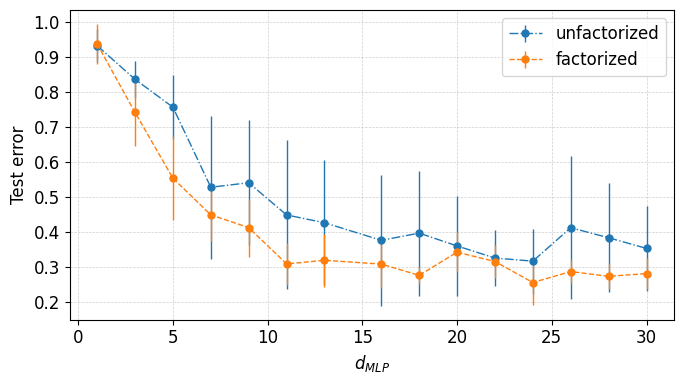

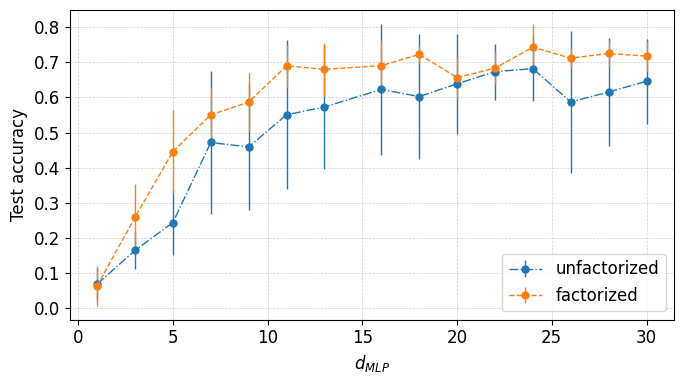

In [141]:
alpha_target = 10.0
label_error_factor = 100**2
subset_S = df_S[df_S["alpha"] == alpha_target].sort_values("MLP_dim")
subset_tied = df_tied[df_tied["alpha"] == alpha_target].sort_values("MLP_dim")

plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["MLP_dim"],
    subset_S["label_err_mean"] * label_error_factor,
    yerr=subset_S.get("label_err_std", 0) * label_error_factor,
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="unfactorized",    
    linestyle='-.'
)

plt.errorbar(
    subset_tied["MLP_dim"],
    subset_tied["label_err_mean"] * label_error_factor,
    yerr=subset_tied.get("label_err_std", 0) * label_error_factor,
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="factorized",
    linestyle='--'
)

plt.xlabel(r"$d_{MLP}$")
plt.ylabel("Test error")
# plt.title(fr"Test error vs MLP dim (α = {alpha_target})")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()

plt.savefig(
    os.path.join(plot_path, f"label_error_vs_MLPdim_alpha{alpha_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["MLP_dim"],
    subset_S["acc_test_mean"],
    yerr=subset_S.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="unfactorized",
    linestyle='-.'
)

plt.errorbar(
    subset_tied["MLP_dim"],
    subset_tied["acc_test_mean"],
    yerr=subset_tied.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="factorized",
    linestyle='--'
)

plt.xlabel(r"$d_{MLP}$")
plt.ylabel("Test accuracy")
# plt.title(fr"Test accuracy vs MLP dim (α = {alpha_target})")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.legend(loc="lower right") 

plt.savefig(
    os.path.join(plot_path, f"Test accuracyr_vs_MLPdim_alpha{alpha_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Label error + ACC vs. alpha (d_MLP fix)

In [142]:
run_id_S = "20251201_2051"
run_id_tied = "20251201_1537"

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

plot_path = f"../results/S_tied/"
os.makedirs(plot_path, exist_ok=True)

# --- Read the CSV file ---
df_S = pd.read_csv(base_path_S)
print(f"✅ Summary loaded ({len(df_S)} rows) from {base_path_S}")
display(df_S.head())

# --- Read the CSV file ---
df_tied = pd.read_csv(base_path_tied)
print(f"✅ Summary loaded ({len(df_tied)} rows) from {base_path_tied}")
display(df_tied.head())

plt.rcParams.update({'font.size': 12}) 

✅ Summary loaded (60 rows) from ../results/run_20251201_2051/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.807143,5,1.0,0.000091,0.000004,0.000139,0.000016,0.000155,0.000024,0.088472,0.038334,0.146292,0.050567,0.480940,0.088287,99.30,1.031095,98.05,2.645254
1,0.807143,10,1.0,0.000091,0.000003,0.000101,0.000023,0.000123,0.000011,0.088889,0.025886,0.234550,0.051294,0.597160,0.056427,99.35,0.875094,99.60,0.502625
2,0.807143,30,1.0,0.000082,0.000004,0.000040,0.000030,0.000070,0.000008,0.179583,0.040986,0.354131,0.055964,0.851907,0.049187,99.60,0.502625,99.85,0.366348
3,0.807143,50,1.0,0.000082,0.000004,0.000024,0.000031,0.000055,0.000007,0.184167,0.035824,0.446964,0.073917,0.914332,0.043813,99.30,0.732695,99.80,0.410391
4,0.100000,5,1.0,0.000089,0.000008,0.000010,0.000018,0.000029,0.000027,0.109167,0.075408,0.604700,0.199878,0.967167,0.086955,99.05,0.825578,96.75,3.242400


✅ Summary loaded (60 rows) from ../results/run_20251201_1537/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.100000,5,1.0,0.000096,0.000002,2.745174e-06,0.000013,0.000016,6.407575e-06,0.040000,0.024423,1.000000,0.000000,0.989829,0.018812,99.80,0.410391,99.50,0.888523
1,0.100000,10,1.0,0.000083,0.000002,1.147868e-06,0.000011,0.000013,2.792606e-06,0.170833,0.020142,1.000000,0.000000,0.998871,0.003916,99.55,0.759155,99.70,0.571241
2,0.100000,30,1.0,0.000088,0.000008,7.968677e-07,0.000011,0.000012,1.260433e-06,0.122500,0.082412,0.955733,0.074443,1.000000,0.000000,99.65,0.489360,99.20,0.523148
3,0.100000,50,1.0,0.000097,0.000003,5.808530e-07,0.000008,0.000009,3.813734e-07,0.030833,0.034317,0.035413,0.065155,1.000000,0.000000,99.10,0.552506,98.60,1.142481
4,0.807143,5,1.0,0.000069,0.000005,1.417255e-04,0.000019,0.000160,1.682212e-05,0.313889,0.045963,0.380205,0.045795,0.486110,0.072910,100.00,0.000000,99.65,0.489360


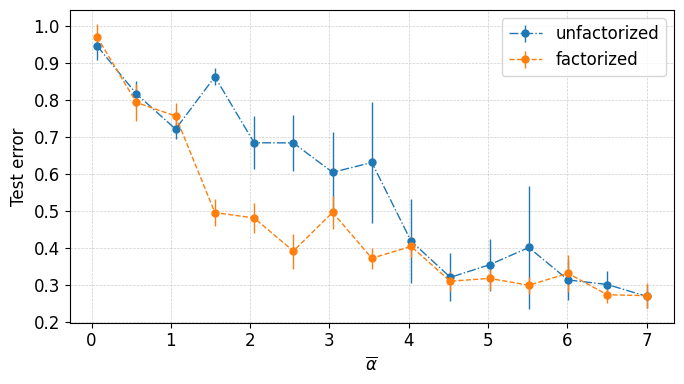

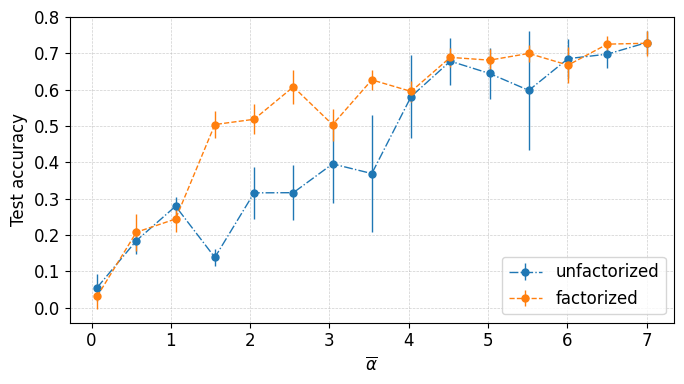

In [143]:
MLP_target = 50  # <-- choisis ton d_MLP
factor = 0.7 # conversion pour alpha_bar n_train 

subset_S = df_S[df_S["MLP_dim"] == MLP_target].sort_values("alpha")
subset_tied = df_tied[df_tied["MLP_dim"] == MLP_target].sort_values("alpha")

# -------------------- LABEL ERROR --------------------
plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["alpha"] * factor,
    subset_S["label_err_mean"] * label_error_factor,
    yerr=subset_S.get("label_err_std", 0) * label_error_factor,
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="unfactorized",
    linestyle='-.'
)

plt.errorbar(
    subset_tied["alpha"] * factor,
    subset_tied["label_err_mean"] * label_error_factor,
    yerr=subset_tied.get("label_err_std", 0) * label_error_factor,
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="factorized",
    linestyle='--'
)

plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test error")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()

plt.savefig(
    os.path.join(plot_path, f"label_error_vs_alpha_MLP{MLP_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# -------------------- TEST ACCURACY --------------------
plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["alpha"] * factor,
    subset_S["acc_test_mean"],
    yerr=subset_S.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="unfactorized",
    linestyle='-.'
)

plt.errorbar(
    subset_tied["alpha"] * factor,
    subset_tied["acc_test_mean"],
    yerr=subset_tied.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="factorized",
    linestyle='--'
)

plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test accuracy")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.legend(loc='lower right')

plt.savefig(
    os.path.join(plot_path, f"test_accuracy_vs_alpha_MLP{MLP_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Impact de fine-tune 

In [144]:
run_id_S = "20251214_1318"
run_id_tied = "20251214_1206"

run_dir_S = f"../results/run_{run_id_S}/"
config_path_S = f"../results/run_{run_id_S}/config.csv"
base_path_S = f"../results/run_{run_id_S}/summary.csv"

run_dir_tied = f"../results/run_{run_id_tied}/"
config_path_tied = f"../results/run_{run_id_tied}/config.csv"
base_path_tied = f"../results/run_{run_id_tied}/summary.csv"

plot_path = f"../results/S_tied/"
os.makedirs(plot_path, exist_ok=True)

# --- Read the CSV file ---
df_S = pd.read_csv(base_path_S)
print(f"✅ Summary loaded ({len(df_S)} rows) from {base_path_S}")
display(df_S.head())

# --- Read the CSV file ---
df_tied = pd.read_csv(base_path_tied)
print(f"✅ Summary loaded ({len(df_tied)} rows) from {base_path_tied}")
display(df_tied.head())

plt.rcParams.update({'font.size': 12}) 

✅ Summary loaded (14 rows) from ../results/run_20251214_1054/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.100000,50,1.0,0.848598,0.010456,0.000051,0.000010,0.000061,0.000041,0.151402,0.010456,0.138539,0.157846,0.786848,0.167047,100.0,0.000000,99.95,0.223607
1,2.235714,50,1.0,0.808153,0.016777,0.000116,0.000020,0.000135,0.000036,0.191847,0.016777,0.530280,0.343701,0.575435,0.156997,96.7,5.611079,96.75,4.788968
2,4.371429,50,1.0,0.813905,0.037775,0.000115,0.000024,0.000139,0.000026,0.186095,0.037775,0.913176,0.189745,0.581828,0.113937,95.1,7.906693,95.40,8.586403
3,6.507143,50,1.0,0.743558,0.067893,0.000116,0.000024,0.000139,0.000024,0.256442,0.067893,0.931706,0.122706,0.574354,0.108473,94.3,9.782369,97.10,2.613729
4,10.778571,50,1.0,0.765968,0.081652,0.000119,0.000023,0.000141,0.000017,0.234032,0.081652,0.685601,0.249036,0.556533,0.094078,97.0,4.304221,92.20,7.709188


✅ Summary loaded (15 rows) from ../results/run_20251214_1206/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,train_total_std,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.100000,50,1.0,0.826607,0.005738,8.077380e-07,0.000011,0.000011,4.949955e-07,0.173393,0.005738,0.212136,0.008848,1.000000,0.000000,99.55,0.510418,96.50,2.585384
1,1.514286,50,1.0,0.544317,0.028369,4.201352e-05,0.000034,0.000076,1.733317e-05,0.455683,0.028369,0.443923,0.024229,0.853024,0.108142,95.90,4.678056,96.55,2.625282
2,0.807143,50,1.0,0.689352,0.021778,3.471035e-05,0.000031,0.000066,4.976274e-05,0.310648,0.021778,0.364369,0.027719,0.864414,0.214645,97.10,3.110255,99.35,0.745160
3,2.221429,50,1.0,0.435225,0.026296,3.666059e-05,0.000038,0.000074,1.862875e-05,0.564775,0.026296,0.608998,0.032073,0.866828,0.109249,95.00,4.116718,95.75,3.416292
4,3.635714,50,1.0,0.351505,0.039557,6.046230e-05,0.000037,0.000097,1.522580e-05,0.648495,0.039557,0.693098,0.041325,0.778469,0.096574,89.95,8.178759,93.65,7.982052


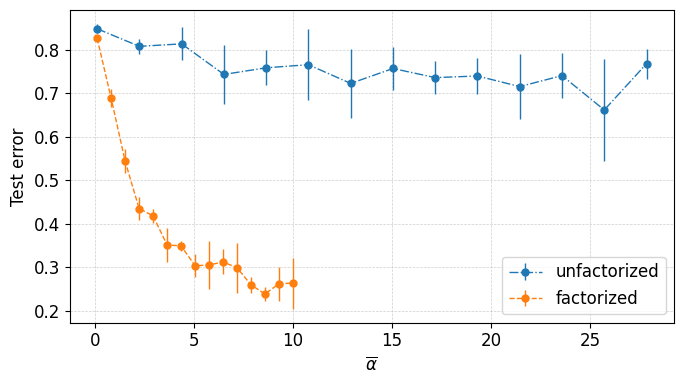

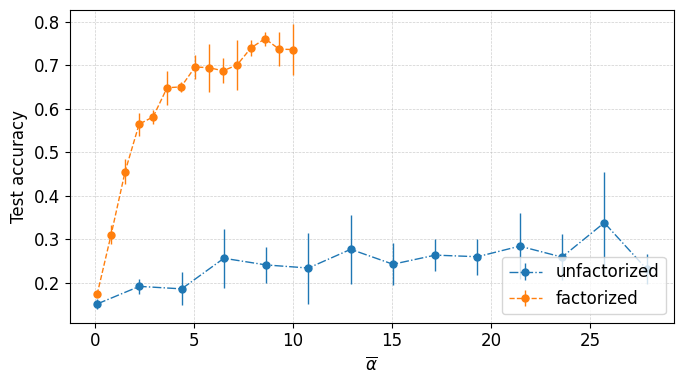

In [145]:
MLP_target = 50  # <-- choisis ton d_MLP
factor = 0.7 # conversion pour alpha_bar n_train 

subset_S = df_S[df_S["MLP_dim"] == MLP_target].sort_values("alpha")
subset_tied = df_tied[df_tied["MLP_dim"] == MLP_target].sort_values("alpha")

# -------------------- LABEL ERROR --------------------
plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["alpha"],
    subset_S["label_err_mean"],
    yerr=subset_S.get("label_err_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="unfactorized",
    linestyle='-.'
)

plt.errorbar(
    subset_tied["alpha"],
    subset_tied["label_err_mean"],
    yerr=subset_tied.get("label_err_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="factorized",
    linestyle='--'
)

plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test error")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()

plt.savefig(
    os.path.join(plot_path, f"label_error_vs_alpha_MLP{MLP_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# -------------------- TEST ACCURACY --------------------
plt.figure(figsize=(7, 4))

plt.errorbar(
    subset_S["alpha"],
    subset_S["acc_test_mean"],
    yerr=subset_S.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="unfactorized",
    linestyle='-.'
)

plt.errorbar(
    subset_tied["alpha"],
    subset_tied["acc_test_mean"],
    yerr=subset_tied.get("acc_test_std", 0),
    marker='o',
    markersize=5,
    linewidth=1,
    capsize=0,
    label="factorized",
    linestyle='--'
)

plt.xlabel(r"$\overline{\alpha}$")
plt.ylabel("Test accuracy")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.legend(loc='lower right')

plt.savefig(
    os.path.join(plot_path, f"test_accuracy_vs_alpha_MLP{MLP_target}_run{run_id_S}.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()